In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

import os
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")
print("GPU devices available:", tf.config.list_physical_devices('GPU'))

Versão do TensorFlow: 2.19.0
Dispositivos GPU disponíveis: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Montar o Google Drive e Configuração Inicial

In [4]:
from google.colab import drive
import os
import tensorflow as tf

drive.mount('/content/drive')
DRIVE_PROJECT_PATH = '/content/drive/MyDrive/diabetes-lesion-analysis'

if os.path.isdir(DRIVE_PROJECT_PATH):
    print(f"Caminho do projeto encontrado: {DRIVE_PROJECT_PATH}")
else:
    print(f"ERRO: Caminho não encontrado. Verifique se o diretório existe: {DRIVE_PROJECT_PATH}")

CLASSES = ['BG', 'D', 'N', 'P', 'S', 'V'] # 6 classes (Background, Diabetic Foot Ulcer, Normal Skin, Pressure Ulcer, Surgical Wound, Venous Leg Ulcer)
NUM_CLASSES = len(CLASSES)

TRAIN_DIR = os.path.join(DRIVE_PROJECT_PATH, 'dataset/train')
TEST_DIR = os.path.join(DRIVE_PROJECT_PATH, 'dataset/test')

print(f"Diretório de Treinamento: {TRAIN_DIR}")
print(f"Diretório de Teste: {TEST_DIR}")

Mounted at /content/drive
Caminho do projeto encontrado: /content/drive/MyDrive/diabetes-lesion-analysis
Diretório de Treinamento: /content/drive/MyDrive/diabetes-lesion-analysis/dataset/train
Diretório de Teste: /content/drive/MyDrive/diabetes-lesion-analysis/dataset/test


## Configurações e Data Augmentation

In [5]:
# Parâmetros da Imagem e Treinamento
IMG_SIZE = (224, 224) # Tamanho padrão para VGG16
BATCH_SIZE = 32
INPUT_SHAPE = IMG_SIZE + (3,) # (224, 224, 3)

# 1. Data Augmentation (APENAS para o conjunto de TREINO)
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalização (fundamental)
    rotation_range=20, # Rotação aleatória de até 20 graus
    width_shift_range=0.2, # Deslocamento horizontal
    height_shift_range=0.2, # Deslocamento vertical
    shear_range=0.2, # Distorção de cisalhamento
    zoom_range=0.2, # Zoom aleatório
    horizontal_flip=True, # Inversão horizontal
    fill_mode='nearest'
)

# 2. Rescale (APENAS para o conjunto de TESTE)
test_datagen = ImageDataGenerator(rescale=1./255) # Apenas normalização

# Geração dos Batches de Dados a partir das pastas
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Modo categórico para classificação multi-classe
    classes=CLASSES,
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=False
)

Found 696 images belonging to 6 classes.
Found 234 images belonging to 6 classes.


## Construção do Modelo (VGG16 Transfer Learning)

In [6]:
# 1. Carregar o modelo base pré-treinado (VGG16)
base_model = VGG16(
    weights='imagenet', # Usar pesos pré-treinados no ImageNet
    include_top=False, # Excluir a camada densa final (para adaptar ao nosso problema de 6 classes)
    input_shape=INPUT_SHAPE
)

# 2. Congelar as camadas convolucionais do modelo base (Transfer Learning)
# Isso evita que os pesos pré-treinados sejam modificados durante o treinamento inicial
for layer in base_model.layers:
    layer.trainable = False

# 3. Construir o novo 'cabeçalho' de classificação
x = base_model.output
x = Flatten()(x) # Aplanar a saída da última camada convolucional
x = Dense(512, activation='relu')(x) # Camada Densa com 512 neurônios
x = Dropout(0.5)(x) # Dropout para regularização
x = Dense(256, activation='relu')(x) # Segunda camada Densa
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x) # Camada final para 6 classes

# 4. Combinar o modelo base com o novo cabeçalho
model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compilar o modelo
model.compile(
    optimizer=Adam(learning_rate=0.0001), # Taxa de aprendizado baixa para Fine-tuning
    loss='categorical_crossentropy', # Loss function para múltiplas classes com one-hot encoding (categorical)
    metrics=['accuracy']
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,54

 Total params: 27,693,126 (105.64 MB)

 Trainable params: 12,978,438 (49.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Treinamento + Callbacks para salvar o melhor modelo e Early Stopping

In [7]:
checkpoint = ModelCheckpoint(
    'best_wound_classifier.h5', # Nome do arquivo de saída
    monitor='val_accuracy', # Monitorar a acurácia de validação
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10, # Esperar 10 épocas sem melhora antes de parar
    restore_best_weights=True
)

callbacks_list = [checkpoint, early_stopping]

# 2. Treinamento
EPOCHS = 100 # It could be bigger.

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE,
    callbacks=callbacks_list
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1960 - loss: 2.1792
Epoch 1: val_accuracy improved from -inf to 0.30357, saving model to best_wound_classifier.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 226s 10s/step - accuracy: 0.1972 - loss: 2.1720 - val_accuracy: 0.3036 - val_loss: 1.6147
Epoch 2/100
 1/21 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.1875 - loss: 2.0057

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.30357
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - accuracy: 0.1875 - loss: 2.0057 - val_accuracy: 0.2902 - val_loss: 1.6073
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.2763 - loss: 1.7311
Epoch 3: val_accuracy improved from 0.30357 to 0.43304, saving model to best_wound_classifier.h5


...

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.6562 - loss: 0.8721 - val_accuracy: 0.6161 - val_loss: 1.0221
Epoch 27/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.5573 - loss: 1.1287
Epoch 27: val_accuracy improved from 0.61607 to 0.65625, saving model to best_wound_classifier.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 600ms/step - accuracy: 0.5575 - loss: 1.1304 - val_accuracy: 0.6562 - val_loss: 1.0128
Epoch 28/100
 1/21 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - accuracy: 0.5938 - loss: 1.0002
Epoch 28: val_accuracy did not improve from 0.65625
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.5938 - loss: 1.0002 - val_accuracy: 0.6205 - val_loss: 1.0167
Epoch 29/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.5666 - loss: 1.1512
Epoch 29: val_accuracy did not improve from 0.65625
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 590ms/step - accuracy: 0.5663 - loss: 1.1523 - val_accuracy: 0.6027 - val_loss: 1.0180
Epoch 30/100
 1/21 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - accuracy: 0.4062 - loss: 1.4399
Epoch 30: val_accuracy did not improve from 0.65625
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.4062 - loss: 1.4399 - val_accuracy: 0.6071 - val_loss: 1.0095
Epoch 31/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.5934 - loss: 1.1052
Epoch 31: val_accuracy d

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.6875 - loss: 1.0407 - val_accuracy: 0.6607 - val_loss: 0.9640
Epoch 35/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.6037 - loss: 1.0442
Epoch 35: val_accuracy did not improve from 0.66071
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 583ms/step - accuracy: 0.6031 - loss: 1.0451 - val_accuracy: 0.6607 - val_loss: 0.9372
Epoch 36/100
 1/21 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step - accuracy: 0.5938 - loss: 1.1487
Epoch 36: val_accuracy did not improve from 0.66071
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.5938 - loss: 1.1487 - val_accuracy: 0.6607 - val_loss: 0.9320
Epoch 37/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.6107 - loss: 1.0374
Epoch 37: val_accuracy did not improve from 0.66071
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 567ms/step - accuracy: 0.6093 - loss: 1.0399 - val_accuracy: 0.6518 - val_loss: 0.9416
Epoch 38/100
 1/21 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - accuracy: 0.7500 - loss: 0.8469
Epoch 38: val_accuracy d

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.7188 - loss: 0.9841 - val_accuracy: 0.6875 - val_loss: 0.9142
Epoch 43/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.6190 - loss: 1.0324
Epoch 43: val_accuracy did not improve from 0.68750
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 615ms/step - accuracy: 0.6193 - loss: 1.0324 - val_accuracy: 0.6786 - val_loss: 0.9000
Epoch 44/100
 1/21 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - accuracy: 0.6250 - loss: 0.9865
Epoch 44: val_accuracy did not improve from 0.68750
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.6250 - loss: 0.9865 - val_accuracy: 0.6741 - val_loss: 0.9060
Epoch 45/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.6203 - loss: 1.0314
Epoch 45: val_accuracy did not improve from 0.68750
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 611ms/step - accuracy: 0.6213 - loss: 1.0298 - val_accuracy: 0.6473 - val_loss: 0.9162
Epoch 46/100
 1/21 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - accuracy: 0.5625 - loss: 1.0290
Epoch 46: val_accuracy d

21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 640ms/step - accuracy: 0.6575 - loss: 0.9584 - val_accuracy: 0.7054 - val_loss: 0.8611
Epoch 54/100
 1/21 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.7500 - loss: 0.8682
Epoch 54: val_accuracy did not improve from 0.70536
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.7500 - loss: 0.8682 - val_accuracy: 0.7009 - val_loss: 0.8568
Epoch 55/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.6170 - loss: 0.9596
Epoch 55: val_accuracy did not improve from 0.70536
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 605ms/step - accuracy: 0.6172 - loss: 0.9605 - val_accuracy: 0.6473 - val_loss: 0.9064
Epoch 56/100
 1/21 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - accuracy: 0.6562 - loss: 0.8816
Epoch 56: val_accuracy did not improve from 0.70536
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.6562 - loss: 0.8816 - val_accuracy: 0.6696 - val_loss: 0.8935
Epoch 57/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.6363 - loss: 0.9479
Epoch 57: val_accuracy d

### Análise de Métricas e Visualização

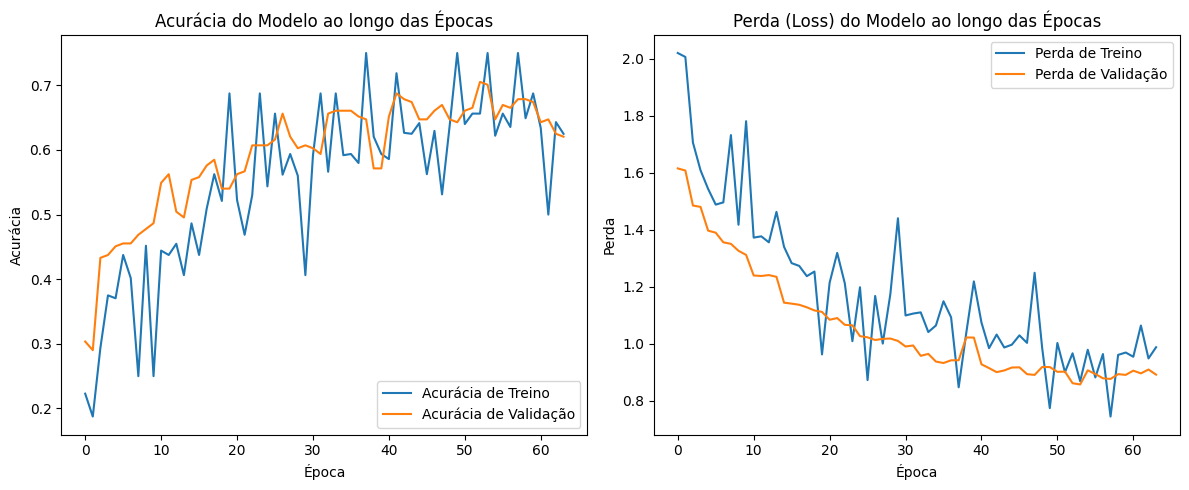


--- Gerando Previsões no Conjunto de Teste ---
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 968ms/step


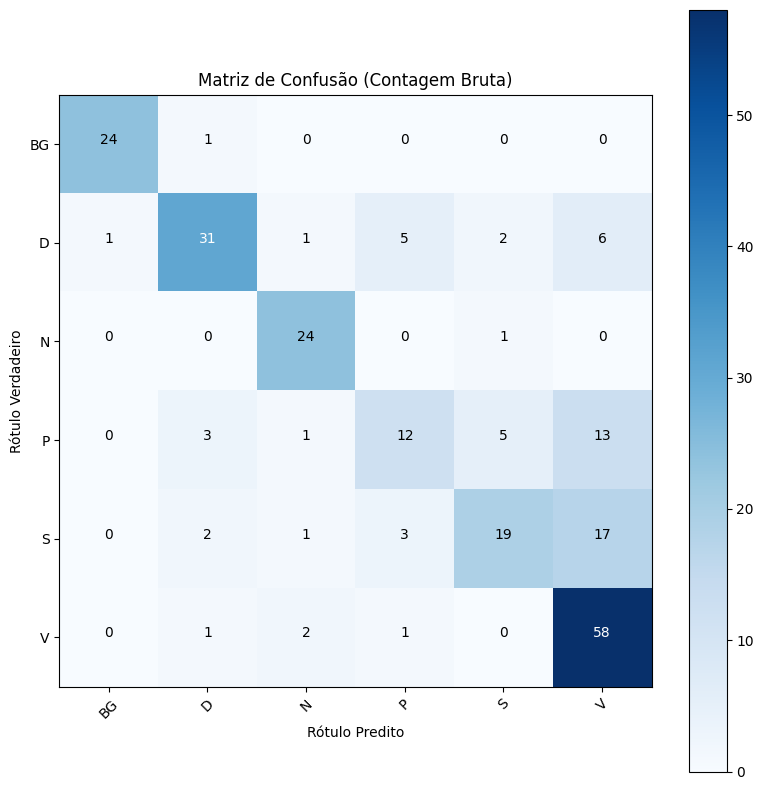

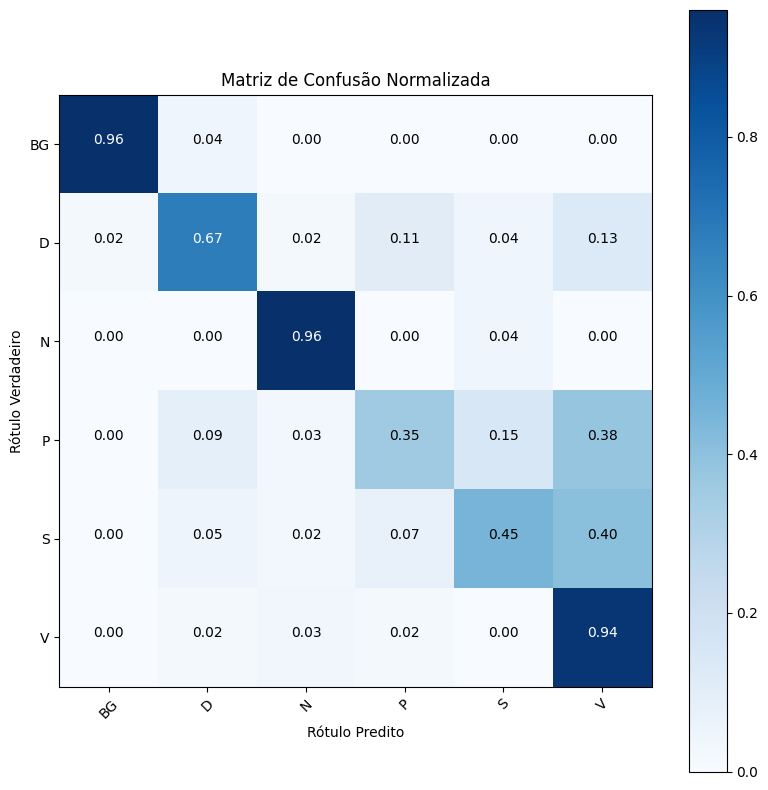


--- Relatório Detalhado de Classificação (Precision, Recall, F1) ---
              precision    recall  f1-score   support

          BG       0.96      0.96      0.96        25
           D       0.82      0.67      0.74        46
           N       0.83      0.96      0.89        25
           P       0.57      0.35      0.44        34
           S       0.70      0.45      0.55        42
           V       0.62      0.94      0.74        62

    accuracy                           0.72       234
   macro avg       0.75      0.72      0.72       234
weighted avg       0.72      0.72      0.70       234


--- Tabela de Métricas por Classe ---
              precision    recall  f1-score     support
BG             0.960000  0.960000  0.960000   25.000000
D              0.815789  0.673913  0.738095   46.000000
N              0.827586  0.960000  0.888889   25.000000
P              0.571429  0.352941  0.436364   34.000000
S              0.703704  0.452381  0.550725   42.000000
V           

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import pandas as pd

final_model = tf.keras.models.load_model('best_wound_classifier.h5')

# 1. Gráficos de Acurácia e Perda (Loss) ao longo das Épocas
plt.figure(figsize=(12, 5))

# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Acurácia de Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
plt.title('Acurácia do Modelo ao longo das Épocas')
plt.ylabel('Acurácia')
plt.xlabel('Época')
plt.legend(loc='lower right')

# Gráfico de Perda (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Perda de Treino')
plt.plot(history.history['val_loss'], label='Perda de Validação')
plt.title('Perda (Loss) do Modelo ao longo das Épocas')
plt.ylabel('Perda')
plt.xlabel('Época')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# 2. Previsões e Matriz de Confusão
print("\n--- Gerando Previsões no Conjunto de Teste ---")
# Resetar o gerador de teste para garantir a ordem correta das imagens
test_generator.reset()

# Fazer predições
Y_pred = final_model.predict(
    test_generator,
    steps=test_generator.samples // BATCH_SIZE + 1 # +1 para garantir que todas as amostras sejam incluídas
)

# Obter a classe predita (índice com a maior probabilidade)
y_pred_classes = np.argmax(Y_pred, axis=1)
# Obter a classe verdadeira
y_true_classes = test_generator.classes[:len(y_pred_classes)] # Garante que tenhamos o mesmo número de amostras

# 3. Matriz de Confusão
cm = confusion_matrix(y_true_classes, y_pred_classes)

def plot_confusion_matrix(cm, classes, normalize=False, title='Matriz de Confusão', cmap=plt.cm.Blues):
    """Função auxiliar para plotar a matriz de confusão."""
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        title = 'Matriz de Confusão Normalizada'

    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('Rótulo Verdadeiro')
    plt.xlabel('Rótulo Predito')
    plt.show()

# Plotar a matriz de confusão não normalizada
plot_confusion_matrix(cm, classes=CLASSES, title='Matriz de Confusão (Contagem Bruta)')

# Plotar a matriz de confusão normalizada (para ver percentuais de acerto/erro por classe)
plot_confusion_matrix(cm, classes=CLASSES, normalize=True, title='Matriz de Confusão Normalizada (%)')

# 4. Relatório de Classificação (Precision, Recall, F1-Score)
report = classification_report(y_true_classes, y_pred_classes, target_names=CLASSES)
print("\n--- Relatório Detalhado de Classificação (Precision, Recall, F1) ---")
print(report)

# DataFrame com o relatório para facilitar a visualização e exportação
report_df = pd.DataFrame(classification_report(y_true_classes, y_pred_classes, target_names=CLASSES, output_dict=True)).transpose()
print("\n--- Tabela de Métricas por Classe ---")
print(report_df)

### Exportação do Modelo BASELINE (74.79%) - Para Backup

In [9]:
# 'best_wound_classifier.h5' ===> 74.79%

# Nome do arquivo de modelo local
BASELINE_H5_FILENAME = 'best_wound_classifier.h5'

# Carregar o modelo BASELINE do disco
final_model_baseline = tf.keras.models.load_model(BASELINE_H5_FILENAME)

# --- Exportar para o Google Drive ---
MODEL_SAVE_PATH = os.path.join(DRIVE_PROJECT_PATH, 'modelos_salvos')
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# 1. Exportar o modelo no formato SafeModel (com nome BASELINE)
final_model_baseline_path_safe = os.path.join(MODEL_SAVE_PATH, 'saved_model_BASELINE')
final_model_baseline.export(final_model_baseline_path_safe)

# 2. Copia o arquivo .h5 local para o Drive com o nome BASELINE
!cp "$BASELINE_H5_FILENAME" "$MODEL_SAVE_PATH/best_wound_classifier_BASELINE.h5"

print(f"\n✅ Exportação do BASELINE concluída!")
print(f"Modelo Baseline (.h5 e SafeModel) salvo com sucesso no Drive: {MODEL_SAVE_PATH}")

Saved artifact at '/content/drive/MyDrive/diabetes-lesion-analysis/modelos_salvos/saved_model_BASELINE'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')]
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  134411411562256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134411411560528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134411411563216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134411411560912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134411411563600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134411411563408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134411411563984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134411411563792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134411411564368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134411411564

# Fine Tuning

#### Configuração e Descongelamento para Fine-Tuning

In [10]:
# Carregar o melhor modelo treinado até agora
fine_tune_model = tf.keras.models.load_model('best_wound_classifier.h5')

# 1. Determinar o Ponto de Corte para Descongelamento
# Queremos descongelar o último bloco convolucional (block5) da VGG16.
# A VGG16 tem 19 camadas na base. Vamos verificar a camada 15 (block5_conv1).
# Iremos descongelar a partir da camada 15 ou 16 (verifique o summary da Célula 3)
FINE_TUNE_AT = 15 # Começar a descongelar a partir da camada 'block5_conv1'

# 2. Descongelar as camadas para Fine-Tuning
for layer in fine_tune_model.layers:
    if layer.name.startswith('block5') or layer.name in ['flatten', 'dense', 'dense_1', 'dense_2', 'dropout', 'dropout_1']:
        layer.trainable = True
    else:
        layer.trainable = False

# Opcionalmente, pode-se fazer de forma mais simples desativando todas e reativando a partir do índice:
# for layer in fine_tune_model.layers[:FINE_TUNE_AT]:
#     layer.trainable = False
# for layer in fine_tune_model.layers[FINE_TUNE_AT:]:
#     layer.trainable = True

# 3. Recompilar o modelo com uma Taxa de Aprendizado MUITO BAIXA
# Isso é CRUCIAL. Uma taxa alta estragaria os pesos pré-treinados da VGG16.
FINE_TUNE_LR = 1e-5

fine_tune_model.compile(
    optimizer=Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Modelo configurado para Fine-Tuning:")
fine_tune_model.summary(line_length=150)

# Verificar quantas camadas estão treináveis agora
print(f"\nNúmero de camadas treináveis: {sum([1 for layer in fine_tune_model.trainable_variables])}")

Modelo configurado para Fine-Tuning:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                                     ┃ Output Shape                                  
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ input_layer (InputLayer)                                         │ (None, 224, 224, 3)                           
├──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────
│ block1_conv1 (Conv2D)                                            │ (None, 224, 224, 64)                          
├──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────
│ block1_conv2 (Conv2D)                                            │ (None, 224, 224, 64)                          
├──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────
│ block1_pool (MaxPooling2D)                                       │ (None, 112, 112, 64)                          
├──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────
│ block2_conv1 (Conv2D)                                            │ (None, 112, 112, 128)                         
├──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────
│ block2_conv2 (Conv2D)                                            │ (None, 112, 112, 128)                         
├──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────
│ block2_pool (MaxPooling2D)                                       │ (None, 56, 56, 128)                           
├──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────
│ block3_conv1 (Conv2D)                                            │ (None, 56, 56, 256)                           
├──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────
│ block3_conv2 (Conv2D)                                            │ (None, 56, 56, 256)                           
├──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────
│ block3_conv3 (Conv2D)                                            │ (None, 56, 56, 256)                           
├──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────
│ block3_pool (MaxPooling2D)                                       │ (None, 28, 28, 256)                           
├──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────
│ block4_conv1 (Conv2D)                                            │ (None, 28, 28, 512)                           
├──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────
│ block4_conv2 (Conv2D)                                            │ (None, 28, 28, 512)                           
├──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────
│ block4_conv3 (Conv2D)                                            │ (None, 28, 28, 512)                           
├──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────
│ block4_pool (MaxPooling2D)                                       │ (None, 14, 14, 512)                           
├──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────
│ block5_conv1 (Conv2D)                                            │ (None, 14, 14, 512)                           
├───────────────────────────────────────────────────────

 Total params: 27,693,126 (105.64 MB)

 Trainable params: 20,057,862 (76.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)


Número de camadas treináveis: 12


#### Execução do Fine-Tuning

In [11]:
# O checkpoint irá monitorar a performance e salvará APENAS se houver melhora
fine_tune_checkpoint = ModelCheckpoint(
    'best_wound_classifier_finetuned.h5', # Novo nome para o arquivo de melhor modelo
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Early Stopping é nossa proteção principal
fine_tune_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5, # Reduzir a paciência, pois Fine-Tuning é mais volátil
    restore_best_weights=True
)

fine_tune_callbacks = [fine_tune_checkpoint, fine_tune_early_stopping]

# Vamos rodar por menos épocas (ex: 20-30), pois já estamos treinando a partir da Época 94.
FINE_TUNE_EPOCHS = 20

print(f"Iniciando Fine-Tuning por {FINE_TUNE_EPOCHS} épocas (a partir da performance de 74.79%)...")

# Usar os mesmos geradores de dados
fine_tune_history = fine_tune_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=FINE_TUNE_EPOCHS,
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE,
    callbacks=fine_tune_callbacks
)

Iniciando Fine-Tuning por 20 épocas (a partir da performance de 74.79%)...
Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 731ms/step - accuracy: 0.6503 - loss: 0.9444
Epoch 1: val_accuracy improved from -inf to 0.70982, saving model to best_wound_classifier_finetuned.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 30s 919ms/step - accuracy: 0.6501 - loss: 0.9445 - val_accuracy: 0.7098 - val_loss: 0.8284
Epoch 2/20
 1/21 ━━━━━━━━━━━━━━━━━━━━ 1:25 4s/step - accuracy: 0.7083 - loss: 0.9218

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.70982
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.7083 - loss: 0.9218 - val_accuracy: 0.7098 - val_loss: 0.8295
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.6431 - loss: 0.9082
Epoch 3: val_accuracy did not improve from 0.70982
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6431 - loss: 0.9076 - val_accuracy: 0.7054 - val_loss: 0.7933
Epoch 4/20
 1/21 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - accuracy: 0.5625 - loss: 0.9179
Epoch 4: val_accuracy did not improve from 0.70982
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.5625 - loss: 0.9179 - val_accuracy: 0.7054 - val_loss: 0.8015
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.6990 - loss: 0.8513
Epoch 5: val_accuracy improved from 0.70982 to 0.71429, saving model to best_wound_classifier_finetuned.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 753ms/step - accuracy: 0.6986 - loss: 0.8528 - val_accuracy: 0.7143 - val_loss: 0.7886
Epoch 6/20
 1/21 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - accuracy: 0.6562 - loss: 0.8058
Epoch 6: val_accuracy improved from 0.71429 to 0.71875, saving model to best_wound_classifier_finetuned.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 0.6562 - loss: 0.8058 - val_accuracy: 0.7188 - val_loss: 0.7896
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.7013 - loss: 0.8316
Epoch 7: val_accuracy did not improve from 0.71875
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 633ms/step - accuracy: 0.7011 - loss: 0.8307 - val_accuracy: 0.7188 - val_loss: 0.7582
Epoch 8/20
 1/21 ━━━━━━━━━━━━━━━━━━━━ 3s 186ms/step - accuracy: 0.6562 - loss: 0.8376
Epoch 8: val_accuracy did not improve from 0.71875
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.6562 - loss: 0.8376 - val_accuracy: 0.7188 - val_loss: 0.7593
Epoch 9/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.7351 - loss: 0.7781
Epoch 9: val_accuracy improved from 0.71875 to 0.74107, saving model to best_wound_classifier_finetuned.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7335 - loss: 0.7798 - val_accuracy: 0.7411 - val_loss: 0.7302
Epoch 10/20
 1/21 ━━━━━━━━━━━━━━━━━━━━ 3s 181ms/step - accuracy: 0.7812 - loss: 0.6818
Epoch 10: val_accuracy did not improve from 0.74107
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.7812 - loss: 0.6818 - val_accuracy: 0.7366 - val_loss: 0.7362
Epoch 11/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.7089 - loss: 0.8091
Epoch 11: val_accuracy improved from 0.74107 to 0.74554, saving model to best_wound_classifier_finetuned.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 657ms/step - accuracy: 0.7094 - loss: 0.8086 - val_accuracy: 0.7455 - val_loss: 0.7288
Epoch 12/20
 1/21 ━━━━━━━━━━━━━━━━━━━━ 3s 186ms/step - accuracy: 0.7812 - loss: 0.7217
Epoch 12: val_accuracy did not improve from 0.74554
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.7812 - loss: 0.7217 - val_accuracy: 0.7366 - val_loss: 0.7371
Epoch 13/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.7316 - loss: 0.7531
Epoch 13: val_accuracy did not improve from 0.74554
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 627ms/step - accuracy: 0.7318 - loss: 0.7522 - val_accuracy: 0.7277 - val_loss: 0.7308
Epoch 14/20
 1/21 ━━━━━━━━━━━━━━━━━━━━ 3s 195ms/step - accuracy: 0.7188 - loss: 0.8218
Epoch 14: val_accuracy did not improve from 0.74554
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.7188 - loss: 0.8218 - val_accuracy: 0.7232 - val_loss: 0.7303
Epoch 15/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.7053 - loss: 0.7848
Epoch 15: val_accuracy did n

#### Análise do Modelo Fine-Tuned e Comparação

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 241ms/step
--- Resultado FINAL do Fine-Tuning ---
Acurácia Global (Fine-Tuning): 0.7479
--------------------------------------

              precision    recall  f1-score   support

          BG       0.96      0.96      0.96        25
           D       0.85      0.74      0.79        46
           N       0.83      1.00      0.91        25
           P       0.62      0.24      0.34        34
           S       0.60      0.64      0.62        42
           V       0.70      0.92      0.80        62

    accuracy                           0.75       234
   macro avg       0.76      0.75      0.74       234
weighted avg       0.74      0.75      0.73       234



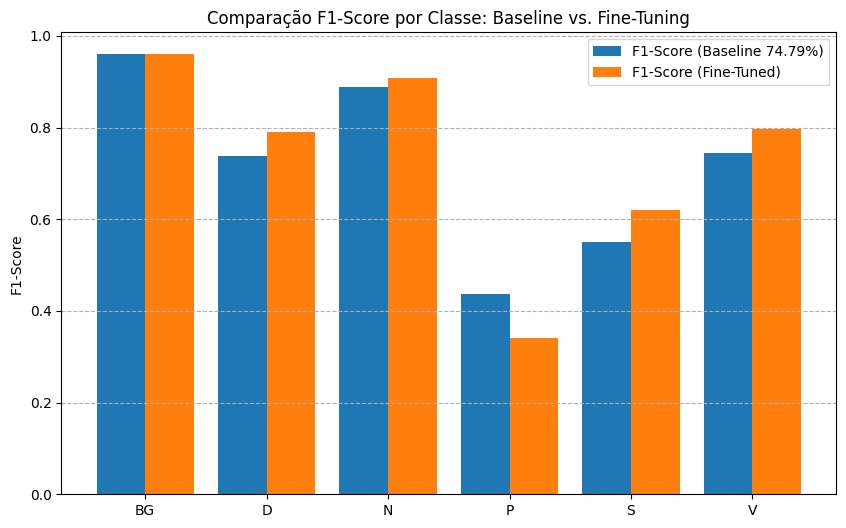


Recall (Baseline P): 0.3529
Recall (Fine-Tuned P): 0.2353


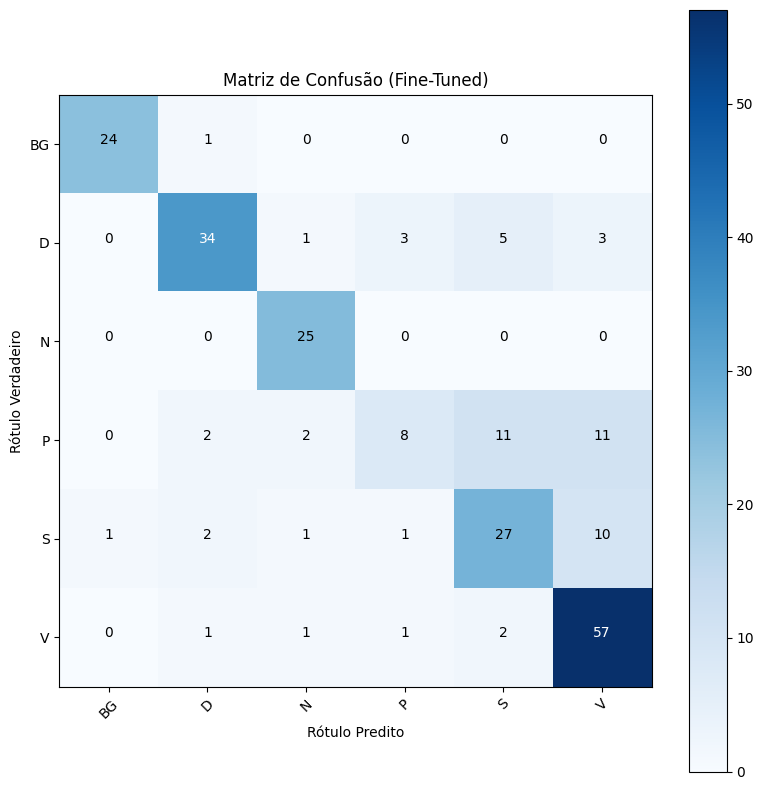

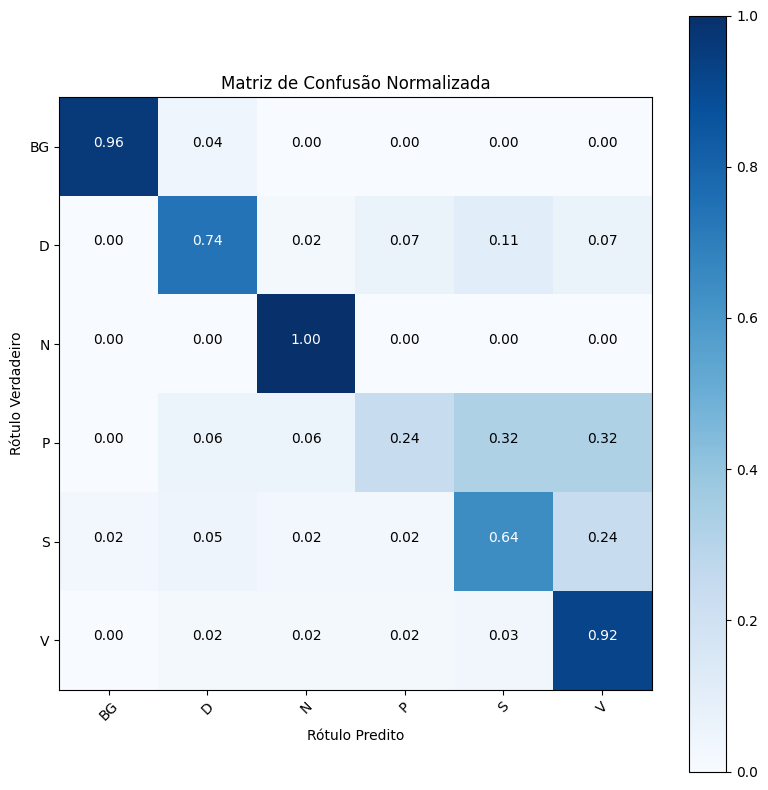

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import itertools
import matplotlib.pyplot as plt

# Carregar o melhor modelo salvo pelo Fine-Tuning
best_finetuned_model = tf.keras.models.load_model('best_wound_classifier_finetuned.h5')

# 1. Gerar Previsões com o modelo Fine-Tuned
test_generator.reset()
Y_pred_ft = best_finetuned_model.predict(
    test_generator,
    steps=test_generator.samples // BATCH_SIZE + 1
)

y_pred_classes_ft = np.argmax(Y_pred_ft, axis=1)
y_true_classes = test_generator.classes[:len(y_pred_classes_ft)]

# 2. Relatório de Classificação (Precision, Recall, F1)
report_ft_dict = classification_report(y_true_classes, y_pred_classes_ft, target_names=CLASSES, output_dict=True)
report_ft_df = pd.DataFrame(report_ft_dict).transpose()

print("--- Resultado FINAL do Fine-Tuning ---")
print(f"Acurácia Global (Fine-Tuning): {report_ft_df.loc['accuracy', 'precision']:.4f}")
print("--------------------------------------\n")
print(classification_report(y_true_classes, y_pred_classes_ft, target_names=CLASSES))

# 3. Comparação F1-Score (Fine-Tuning vs. Baseline)
# Supondo que você rode esta célula APÓS rodar a Célula 6 (onde 'report_df' foi definido)

try:
    baseline_f1 = report_df.loc[CLASSES, 'f1-score'].values
    finetuned_f1 = report_ft_df.loc[CLASSES, 'f1-score'].values

    X_axis = np.arange(len(CLASSES))

    plt.figure(figsize=(10, 6))
    plt.bar(X_axis - 0.2, baseline_f1, 0.4, label = 'F1-Score (Baseline 74.79%)')
    plt.bar(X_axis + 0.2, finetuned_f1, 0.4, label = 'F1-Score (Fine-Tuned)')

    plt.xticks(X_axis, CLASSES)
    plt.ylabel("F1-Score")
    plt.title("Comparação F1-Score por Classe: Baseline vs. Fine-Tuning")
    plt.legend()
    plt.grid(axis='y', linestyle='--')
    plt.show()

    # Foco no Recall da classe P
    print(f"\nRecall (Baseline P): {report_df.loc['P', 'recall']:.4f}")
    print(f"Recall (Fine-Tuned P): {report_ft_df.loc['P', 'recall']:.4f}")

except NameError:
    print("Execute a Célula 6 (Análise de Métricas) primeiro para definir 'report_df' (Baseline).")

# 4. Matriz de Confusão (Nova)
cm_ft = confusion_matrix(y_true_classes, y_pred_classes_ft)

def plot_confusion_matrix(cm, classes, normalize=False, title='Matriz de Confusão', cmap=plt.cm.Blues):
    """Função auxiliar para plotar a matriz de confusão."""
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        title = 'Matriz de Confusão Normalizada'

    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('Rótulo Verdadeiro')
    plt.xlabel('Rótulo Predito')
    plt.show()

# Rodar a função (usando a função definida na Célula 6 ou recriando-a)
plot_confusion_matrix(cm_ft, classes=CLASSES, title='Matriz de Confusão (Fine-Tuned)')
plot_confusion_matrix(cm_ft, classes=CLASSES, normalize=True, title='Matriz de Confusão Normalizada (Fine-Tuned)')

#### Avaliação Final e Exportação

In [13]:
# Carregar o MELHOR modelo, que é o Fine-Tuned
import tensorflow as tf
import os

# Certifique-se de que DRIVE_PROJECT_PATH está acessível ou defina-o novamente
# DRIVE_PROJECT_PATH = '/content/drive/MyDrive/diabetes-lesion-analysis'

# O nome do arquivo .h5 que o callback salvou localmente
H5_FILENAME = 'best_wound_classifier_finetuned.h5'
# O nome do arquivo CSV de métricas que você gerou localmente
CSV_FILENAME = 'wound_metrics_report_FINETUNED.csv'

# Carregar o modelo Fine-Tuned do disco local
final_model = tf.keras.models.load_model(H5_FILENAME)
# Você deve ter definido 'report_ft_df' em uma célula anterior
# final_report_df = report_ft_df

# --- Exportar para o Google Drive ---
MODEL_SAVE_PATH = os.path.join(DRIVE_PROJECT_PATH, 'modelos_salvos')
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# 1. Exportar o modelo no formato SavedModel (CORREÇÃO)
final_model_drive_path_safe = os.path.join(MODEL_SAVE_PATH, 'saved_model_FINETUNED')
final_model.export(final_model_drive_path_safe)

# 2. Copia o arquivo .h5 local para o Drive com um nome único
!cp "$H5_FILENAME" "$MODEL_SAVE_PATH/best_wound_classifier_FINETUNED.h5"

# 3. Copia o relatório CSV local para o Drive
!cp "$CSV_FILENAME" "$MODEL_SAVE_PATH/wound_metrics_report_FINETUNED.csv"

print(f"\n✅ Exportação concluída!")
print(f"Modelo SavedModel salvo para implantação em: {final_model_drive_path_safe}")
print("O Relatório de Métricas FINAL (.csv) também foi exportado.")

Saved artifact at '/content/drive/MyDrive/diabetes-lesion-analysis/modelos_salvos/saved_model_FINETUNED'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')]
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  134410824340432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134410824338704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134410824342928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134410824341584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134410824343888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134410824343696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134410824344272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134410824344080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134410824342544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13441082434